# Notebook 03 — NDVI con Vectores (Shapefiles/GeoJSON): Análisis por Zona

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/miguepoloc/teledeteccion/blob/main/sesiones/sesion-02/colab/03_ndvi_con_shapefiles.ipynb)

## Teledetección — Maestría en Ingeniería, Universidad del Magdalena
**Sesión 2 · Sábado 18 de julio de 2026**

---

### ¿Qué es un Shapefile y por qué está desactualizado?

Históricamente, el formato **Shapefile** de ESRI ha sido el estándar más utilizado en los Sistemas de Información Geográfica (SIG/GIS) para almacenar geometrías (puntos, líneas y polígonos) y sus bases de datos asociadas.

Sin embargo, en el desarrollo web moderno, la teledetección en la nube (como Google Earth Engine) y la programación con Python, el Shapefile clásico se considera **desactualizado e ineficiente** por las siguientes razones:
1. **Multiautónomo / Multiarchivo:** Un Shapefile no es un solo archivo, sino un conjunto de al menos 3 a 5 archivos obligatorios (`.shp`, `.shx`, `.dbf`, `.prj`, etc.). Si olvidas comprimirlos o mover uno, la capa deja de funcionar.
2. **Nombres de columna limitados:** Las tablas de atributos de los Shapefiles están basadas en el formato DBF de los años 80, lo que limita los nombres de las columnas a un máximo de 10 caracteres.
3. **No optimizado para la web:** Cargar múltiples componentes binarios en entornos como Google Colab es complejo y propenso a errores.

### La alternativa moderna: GeoJSON

En este notebook usaremos **GeoJSON** como alternativa a los Shapefiles. 
* **¿Qué es?** Es un formato abierto basado en JSON (JavaScript Object Notation) para codificar estructuras de datos geográficos.
* **¿Por qué lo preferimos?** Consiste en **un único archivo de texto plano**, muy fácil de leer para humanos, extremadamente rápido para transferir por la web y con soporte nativo e inmediato en Google Earth Engine y Python.

**¿Para qué usamos datos vectoriales (Shapefiles/GeoJSON) en teledetección?**

Para **recortar** nuestro análisis a zonas de interés específicas:
- Calcular el NDVI promedio *solo dentro* del polígono de una finca de cacao.
- Comparar el comportamiento de la vegetación entre diferentes cuencas o municipios.
- Analizar el histórico de cobertura *solo* en reservas forestales delimitadas.

**Analogía:** Si la imagen satelital completa es una hoja de papel grande, el GeoJSON/Shapefile actúa como un "molde de galletas" que corta exactamente la porción que te interesa analizar.

### Qué aprenderás en este notebook
1. Definir zonas de análisis con polígonos vectoriales en GEE.
2. Recortar imágenes de NDVI usando máscaras y geometrías.
3. Calcular estadísticas zonales (media, min, max, desviación estándar).
4. Comparar el NDVI entre diferentes franjas altitudinales de la SNSM.
5. Exportar un GeoJSON vectorial local y cargarlo en GEE.

In [2]:
!pip install geemap --quiet

import ee
import geemap
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ee.Authenticate()
ee.Initialize(project='teledeteccion-miguepoloc')

print("✓ GEE inicializado")

✓ GEE inicializado


---

## Paso 1 — Definir zonas de análisis

Vamos a analizar la zona cacaotera de la SNSM dividida en **tres franjas altitudinales**,
tal como lo hace el Artículo 1 de investigación:

- **Franja Baja** (400–700 m): zona histórica de cacao
- **Franja Media** (700–1200 m): zona de transición café ↔ cacao
- **Franja Alta** (1200–1800 m): zona histórica de café

In [3]:
# ============================================================
# DEFINIR ZONAS COMO POLÍGONOS (ee.Geometry)
# ============================================================

# Zona de estudio general (norte del Magdalena + SNSM)
zona_snsm = ee.Geometry.Rectangle([-74.2, 10.5, -73.8, 11.0])

# Modelo Digital de Elevación SRTM (30 m de resolución)
dem = ee.Image('USGS/SRTMGL1_003')

# Crear máscaras por franja altitudinal usando el DEM
franja_baja  = dem.gte(400).And(dem.lt(700))   # 400–700 m → zona de cacao
franja_media = dem.gte(700).And(dem.lt(1200))  # 700–1200 m → transición
franja_alta  = dem.gte(1200).And(dem.lte(1800)) # 1200–1800 m → zona de café

# Convertir las máscaras a polígonos (vectores)
# Esto permite usarlas como zonas de análisis estadístico
zonas_altitudinales = [
    ('Franja Baja (400–700 m) — Cacao',         franja_baja,  '#2ecc71'),
    ('Franja Media (700–1200 m) — Transición',   franja_media, '#f39c12'),
    ('Franja Alta (1200–1800 m) — Café',         franja_alta,  '#e74c3c'),
]

print("Franjas altitudinales definidas:")
for nombre, _, color in zonas_altitudinales:
    print(f"  {nombre}")

Franjas altitudinales definidas:
  Franja Baja (400–700 m) — Cacao
  Franja Media (700–1200 m) — Transición
  Franja Alta (1200–1800 m) — Café


In [4]:
# ============================================================
# CARGAR SENTINEL-2 Y CALCULAR NDVI
# ============================================================

def preparar_imagen_s2(fecha_inicio, fecha_fin):
    """Carga Sentinel-2, enmascara nubes, calcula NDVI y retorna imagen mediana."""
    def enmascarar_nubes(img):
        scl = img.select('SCL')
        mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
        return img.updateMask(mask)

    img = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(zona_snsm)
        .filterDate(fecha_inicio, fecha_fin)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
        .map(enmascarar_nubes)
        .median()
        .clip(zona_snsm)
    )

    ndvi = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return img.addBands(ndvi).addBands(dem.rename('Elevacion'))

# Imagen 2024 (temporada seca)
imagen_2024 = preparar_imagen_s2('2024-01-01', '2024-03-31')

print("✓ Imagen 2024 preparada con NDVI y DEM")

✓ Imagen 2024 preparada con NDVI y DEM


---

## Paso 2 — Calcular estadísticas de NDVI por franja altitudinal

In [5]:
# ============================================================
# ESTADÍSTICAS DE NDVI POR ZONA
# ============================================================

# Función para calcular estadísticas de NDVI dentro de una máscara
def estadisticas_ndvi(imagen, mascara, zona, escala=30):
    """Calcula estadísticas del NDVI solo donde la máscara = 1."""
    ndvi_enmascarado = imagen.select('NDVI').updateMask(mascara)
    
    stats = ndvi_enmascarado.reduceRegion(
        reducer=ee.Reducer.mean()
            .combine(ee.Reducer.stdDev(), None, True)
            .combine(ee.Reducer.min(), None, True)
            .combine(ee.Reducer.max(), None, True)
            .combine(ee.Reducer.percentile([25, 50, 75]), None, True),
        geometry=zona,
        scale=escala,
        maxPixels=1e9
    ).getInfo()
    
    return stats

# Calcular estadísticas para cada franja
resultados = []

for nombre, mascara, color in zonas_altitudinales:
    print(f"Calculando: {nombre}...")
    stats = estadisticas_ndvi(imagen_2024, mascara, zona_snsm)
    resultados.append({
        'Franja': nombre,
        'NDVI_media':   round(stats.get('NDVI_mean', 0) or 0, 4),
        'NDVI_std':     round(stats.get('NDVI_stdDev', 0) or 0, 4),
        'NDVI_min':     round(stats.get('NDVI_min', 0) or 0, 4),
        'NDVI_max':     round(stats.get('NDVI_max', 0) or 0, 4),
        'NDVI_mediana': round(stats.get('NDVI_p50', 0) or 0, 4),
        'Color': color
    })

df = pd.DataFrame(resultados)
print("\n=== NDVI por Franja Altitudinal — Ene–Mar 2024 ===")
print(df[['Franja', 'NDVI_media', 'NDVI_std', 'NDVI_mediana', 'NDVI_min', 'NDVI_max']].to_string(index=False))

Calculando: Franja Baja (400–700 m) — Cacao...
Calculando: Franja Media (700–1200 m) — Transición...
Calculando: Franja Alta (1200–1800 m) — Café...

=== NDVI por Franja Altitudinal — Ene–Mar 2024 ===
                                Franja  NDVI_media  NDVI_std  NDVI_mediana  NDVI_min  NDVI_max
       Franja Baja (400–700 m) — Cacao      0.7626    0.1151        0.7989    0.1539    0.9481
Franja Media (700–1200 m) — Transición      0.8116    0.0980        0.8457   -0.0413    0.9560
      Franja Alta (1200–1800 m) — Café      0.8302    0.0873        0.8634    0.0030    1.0000


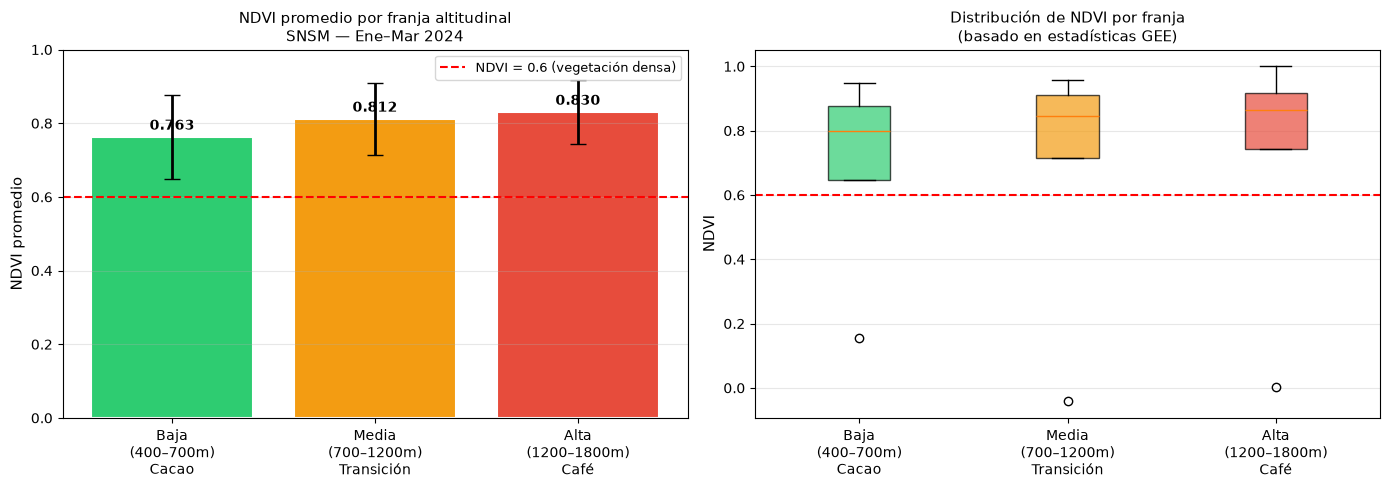

✓ Gráfico guardado


In [7]:
# ============================================================
# VISUALIZAR COMPARACIÓN POR FRANJA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras — NDVI medio por franja
franjas_cortas = ['Baja\n(400–700m)\nCacao', 'Media\n(700–1200m)\nTransición', 'Alta\n(1200–1800m)\nCafé']
colores = [r['Color'] for r in resultados]
medias  = [r['NDVI_media'] for r in resultados]
stds    = [r['NDVI_std'] for r in resultados]

bars = axes[0].bar(franjas_cortas, medias, color=colores, edgecolor='white', linewidth=1.5,
                   yerr=stds, capsize=6, error_kw={'linewidth': 2})
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('NDVI promedio', fontsize=11)
axes[0].set_title('NDVI promedio por franja altitudinal\nSNSM — Ene–Mar 2024', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(0.6, color='red', ls='--', lw=1.5, label='NDVI = 0.6 (vegetación densa)')
axes[0].legend(fontsize=9)

for bar, media in zip(bars, medias):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{media:.3f}', ha='center', fontsize=10, fontweight='bold')

# Boxplot — distribución de NDVI por franja
# (usando los percentiles calculados)
box_data = [
    [r['NDVI_min'], r['NDVI_media'] - r['NDVI_std'],
     r['NDVI_mediana'],
     r['NDVI_media'] + r['NDVI_std'], r['NDVI_max']]
    for r in resultados
]

try:
    bp = axes[1].boxplot(
        [[r['NDVI_min'], r['NDVI_media'] - r['NDVI_std'], r['NDVI_mediana'],
          r['NDVI_media'] + r['NDVI_std'], r['NDVI_max']] for r in resultados],
        tick_labels=franjas_cortas,
        patch_artist=True
    )
except TypeError:
    bp = axes[1].boxplot(
        [[r['NDVI_min'], r['NDVI_media'] - r['NDVI_std'], r['NDVI_mediana'],
          r['NDVI_media'] + r['NDVI_std'], r['NDVI_max']] for r in resultados],
        labels=franjas_cortas,
        patch_artist=True
    )

for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('NDVI', fontsize=11)
axes[1].set_title('Distribución de NDVI por franja\n(basado en estadísticas GEE)', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(0.6, color='red', ls='--', lw=1.5)

plt.tight_layout()
plt.savefig('ndvi_por_franja_snsm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado")

### **Análisis de Resultados: NDVI por Franja Altitudinal (Enero–Marzo 2024)**

Para explicar estos resultados de forma sencilla, podemos dividir la interpretación en tres conceptos clave:

#### **1. El Vigor de la Vegetación y el Umbral Crítico (Línea Roja en 0.6)**
* **¿Qué significa la línea roja en NDVI = 0.6?** En teledetección, un valor de NDVI por encima de 0.6 representa **vegetación densa, sana y en pleno vigor** (como selvas húmedas, bosques espesos o cultivos densos bajo sombrío).
* **Interpretación general:** Las tres franjas analizadas presentan promedios muy superiores a este umbral (Baja: **0.763**, Media: **0.812**, Alta: **0.830**). Esto indica que toda la zona de estudio de la Sierra Nevada de Santa Marta (SNSM) cuenta con una cobertura vegetal muy vigorosa y saludable durante el primer trimestre del año.

#### **2. El Efecto Altitudinal en el Vigor Vegetal (Gráfico de Barras - Izquierda)**
* **Franja Baja (400–700m - Cacao):** Tiene el promedio más bajo (**0.763**). A menor altitud, las temperaturas son más cálidas, hay mayor evaporación del agua y suele haber más intervención humana (claros en el bosque, senderos, zonas construidas).
* **Franja Media (700–1200m - Transición):** Sube a **0.812**, mostrando una transición hacia bosques más continuos y con mejores condiciones de humedad.
* **Franja Alta (1200–1800m - Café):** Tiene el mayor vigor (**0.830**). En esta altitud las temperaturas son más frescas (reduciendo el estrés hídrico de las plantas) y los cultivos de café suelen estar bajo un dosel de sombrío denso (árboles nativos altos), lo que maximiza la cantidad de hojas verdes y saludables que reflejan luz en el Infrarrojo Cercano (NIR).

#### **3. Distribución y Valores Atípicos (Boxplot - Derecha)**
* **La Mediana (Línea naranja dentro de las cajas):** Confirma que la mayoría de los píxeles de la Franja Alta están concentrados en valores muy altos (mediana alrededor de **0.86**).
* **La dispersión (Tamaño de la caja):** La Franja Baja tiene la caja más larga hacia abajo, lo que significa que es un área más heterogénea, con mayor mezcla de vegetación densa y zonas con menos cobertura.
* **Los puntos aislados cerca de 0 (Outliers):** Estos píxeles individuales con valores muy bajos (incluso cercanos a 0 o negativos) **no** significan que el bosque esté muriendo. Representan elementos no vegetales que cayeron dentro del shapefile analizado:
  * **Cuerpos de agua** (ríos o quebradas) que absorben la luz.
  * **Suelo expuesto, rocas o caminos** de tierra.
  * **Sombras de nubes** o nubes residuales que no fueron completamente filtradas por la banda SCL de Sentinel-2.

---

## Paso 3 — Visualizar las franjas en el mapa

In [8]:
# ============================================================
# MAPA CON FRANJAS ALTITUDINALES + NDVI
# ============================================================

paleta_ndvi = ['#d73027', '#f46d43', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641']

mapa = geemap.Map()
mapa.centerObject(zona_snsm, zoom=11)

# NDVI como fondo
mapa.addLayer(
    imagen_2024.select('NDVI'),
    {'min': -0.1, 'max': 0.9, 'palette': paleta_ndvi},
    'NDVI 2024'
)

# Color natural como referencia
mapa.addLayer(
    imagen_2024,
    {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000, 'gamma': 1.4},
    'Color Natural',
    False
)

# DEM para contexto
mapa.addLayer(
    dem.clip(zona_snsm),
    {'min': 0, 'max': 2500, 'palette': ['#a8ddb5', '#43a2ca', '#0868ac']},
    'Elevación (DEM)',
    False
)

# Franjas altitudinales
mapa.addLayer(
    franja_baja.selfMask().clip(zona_snsm),
    {'palette': ['2ecc71'], 'opacity': 0.4},
    'Franja Baja 400–700m (Cacao)'
)
mapa.addLayer(
    franja_media.selfMask().clip(zona_snsm),
    {'palette': ['f39c12'], 'opacity': 0.4},
    'Franja Media 700–1200m (Transición)'
)
mapa.addLayer(
    franja_alta.selfMask().clip(zona_snsm),
    {'palette': ['e74c3c'], 'opacity': 0.4},
    'Franja Alta 1200–1800m (Café)'
)

mapa

Map(center=[10.749994930545569, -73.99999999999935], controls=(WidgetControl(options=['position', 'transparent…

---

## Paso 4 — Usar un shapefile real (GeoJSON)

En la práctica tendrás shapefiles de fincas, municipios o zonas de proyecto.
GEE acepta archivos GeoJSON directamente.

In [10]:
# ============================================================
# EJEMPLO: CREAR UN GEOJSON DE ZONA DE ESTUDIO Y USARLO EN GEE
# ============================================================

# Ejemplo de una zona específica (polígono de una finca hipotética en la SNSM)
# En la práctica, este GeoJSON vendría de tu shapefile exportado desde QGIS

geojson_zona_cacao = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"nombre": "Finca Norte", "cultivo": "cacao"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [-74.00, 10.85], [-73.95, 10.85],
                    [-73.95, 10.90], [-74.00, 10.90],
                    [-74.00, 10.85]
                ]]
            }
        },
        {
            "type": "Feature",
            "properties": {"nombre": "Finca Sur", "cultivo": "cafe"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [-73.92, 10.75], [-73.87, 10.75],
                    [-73.87, 10.80], [-73.92, 10.80],
                    [-73.92, 10.75]
                ]]
            }
        }
    ]
}

# Guardar el GeoJSON como archivo
with open('zonas_cultivo_snsm.geojson', 'w') as f:
    json.dump(geojson_zona_cacao, f)

# Cargar en GEE
try:
    zonas_gee = geemap.geojson_to_ee('zonas_cultivo_snsm.geojson')
except AttributeError:
    # Fallback nativo usando Earth Engine si la versión de geemap no tiene geojson_to_ee
    zonas_gee = ee.FeatureCollection(geojson_zona_cacao)

# Calcular NDVI para cada zona del GeoJSON
def ndvi_por_zona(feature):
    """Calcula NDVI promedio dentro de cada polígono del GeoJSON."""
    geom = feature.geometry()
    ndvi_medio = imagen_2024.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=10,
        maxPixels=1e8
    ).get('NDVI')
    return feature.set('NDVI_promedio', ndvi_medio)

zonas_con_ndvi = zonas_gee.map(ndvi_por_zona)

# Extraer y mostrar resultados
resultados_zonas = zonas_con_ndvi.getInfo()

print("\nNDVI promedio por zona de cultivo:")
print("-" * 50)
for feature in resultados_zonas['features']:
    props = feature['properties']
    ndvi_val = props.get('NDVI_promedio', 'N/A')
    if ndvi_val and ndvi_val != 'N/A':
        ndvi_val = round(ndvi_val, 4)
    print(f"  {props['nombre']} ({props['cultivo']}): NDVI = {ndvi_val}")

print("\nObserva si hay diferencia entre la zona de cacao y la de café.")
print("Esta es la base del Artículo 1 de investigación.")


NDVI promedio por zona de cultivo:
--------------------------------------------------
  Finca Norte (cacao): NDVI = 0.8195
  Finca Sur (cafe): NDVI = 0.8205

Observa si hay diferencia entre la zona de cacao y la de café.
Esta es la base del Artículo 1 de investigación.


In [11]:
# ============================================================
# MAPA FINAL CON ZONAS DE CULTIVO
# ============================================================

mapa2 = geemap.Map()
mapa2.centerObject(zona_snsm, zoom=11)

mapa2.addLayer(
    imagen_2024.select('NDVI'),
    {'min': -0.1, 'max': 0.9, 'palette': paleta_ndvi},
    'NDVI 2024'
)

# Mostrar las zonas del GeoJSON en el mapa
mapa2.addLayer(
    zonas_gee,
    {'color': 'white'},
    'Zonas de cultivo (GeoJSON)'
)

mapa2

Map(center=[10.749994930545569, -73.99999999999935], controls=(WidgetControl(options=['position', 'transparent…

---

## ✅ Resumen — Lo que aprendiste en este notebook

| Concepto | Lo que hiciste |
|----------|---------------|
| Franjas altitudinales | Crear zonas con el DEM (400–700 / 700–1200 / 1200–1800 m) |
| `.updateMask()` | Recortar el NDVI solo a los píxeles de cada franja |
| `.reduceRegion()` | Calcular media, std, min, max, percentiles por zona |
| GeoJSON | Crear y cargar polígonos de zonas de cultivo |
| `.map(función)` | Aplicar una función a cada polígono de una colección |
| Comparación | NDVI cacao vs. café — base del Artículo 1 |

---

## ➡️ Siguiente: Notebook 04 — Todos los índices + cambio temporal

Ahora que dominamos el NDVI y el análisis por zonas, en el Notebook 04 calculamos
NDWI, SAVI, NDRE y EVI — y comparamos 2018 vs. 2024 para ver el cambio café→cacao.